In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import emoji
import html

from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
import evaluate
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import torch

c:\Natural Language Processing\Entity Sentiment Analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('twitter_dataset.csv')
df.head()

,Unnamed: 0,tweet,sentiment
0,0,is upset that he can't update his Facebook by ...,0.0
1,1,@Kenichan I dived many times for the ball. Man...,0.0
2,2,my whole body feels itchy and like its on fire,0.0
3,3,"@nationwideclass no, it's not behaving at all....",0.0
4,4,@Kwesidei not the whole crew,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3142403 entries, 0 to 3142402
Data columns (total 3 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   tweet       str    
 2   sentiment   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 280.8 MB


In [4]:
df = df.drop(columns=['Unnamed: 0'])
df = df.drop_duplicates()
df = df.dropna(subset=['sentiment'])
df = df[df['sentiment'] != 2]
df['sentiment'] = df['sentiment'].astype(int)
df.shape

(3114655, 2)

# EDA

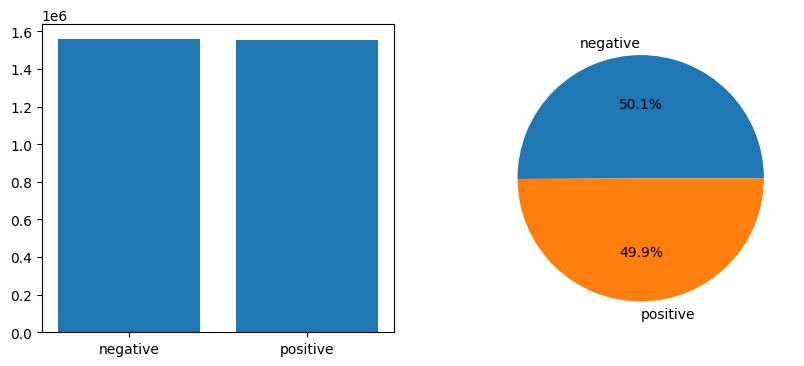

In [5]:
sentiment_count = df['sentiment'].value_counts()
labels = sentiment_count.index.map({0: 'negative', 1: 'positive'})

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(labels, sentiment_count.values)
ax[1].pie(sentiment_count.values, labels=labels, autopct='%1.1f%%')
plt.show()

# Preprocessing

In [6]:
def preprocessing(text: str):
    text = html.unescape(text)
    text = re.sub(r'^RT\s+', '', text)
    text = re.sub(r'http\S+|www\.\S+', 'HTTPURL', text)
    text = re.sub(r'@\w+', '@USER', text)
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df['tweet'] = df['tweet'].apply(preprocessing)
df.head()

# Training Setup

In [ ]:
MAX_ROWS   = 300_000
MAX_EPOCHS = 3
BATCH_SIZE = 32
MAX_LENGTH = 128
NUM_LABELS = 2

In [ ]:
df_compressed, _ = train_test_split(df, train_size=MAX_ROWS, stratify=df['sentiment'], random_state=21)
df_train, df_temp = train_test_split(df_compressed, test_size=0.2, stratify=df_compressed['sentiment'], random_state=21)
df_val,   df_test = train_test_split(df_temp,        test_size=0.5, stratify=df_temp['sentiment'],        random_state=21)

print(f'Train : {len(df_train):,}')
print(f'Val   : {len(df_val):,}')
print(f'Test  : {len(df_test):,}')

In [ ]:
def to_hf_dataset(df):
    ds = Dataset.from_pandas(df[['tweet', 'sentiment']].reset_index(drop=True))
    return ds.rename_columns({'tweet': 'text', 'sentiment': 'label'})

hf_train = to_hf_dataset(df_train)
hf_val   = to_hf_dataset(df_val)
hf_test  = to_hf_dataset(df_test)

print(hf_train)
print(hf_val)
print(hf_test)

In [ ]:
metric_accuracy = evaluate.load('accuracy')
metric_f1       = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = metric_accuracy.compute(predictions=predictions, references=labels)
    f1       = metric_f1.compute(predictions=predictions, references=labels, average='macro')
    return {
        'accuracy' : accuracy['accuracy'],
        'f1_macro' : f1['f1'],
    }

## 1. bert-base-uncased

In [ ]:
MODEL_NAME_1 = 'bert-base-uncased'
tokenizer_1  = AutoTokenizer.from_pretrained(MODEL_NAME_1)

def tokenize_fn_1(examples):
    return tokenizer_1(examples['text'], truncation=True, max_length=MAX_LENGTH)

tok_train_1 = hf_train.map(tokenize_fn_1, batched=True)
tok_val_1   = hf_val.map(tokenize_fn_1, batched=True)
tok_test_1  = hf_test.map(tokenize_fn_1, batched=True)

In [ ]:
model_1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_1, num_labels=NUM_LABELS)

args_1 = TrainingArguments(
    output_dir                  = './models_new/bert-base-uncased',
    num_train_epochs            = MAX_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    fp16                        = True,
    eval_strategy               = 'steps',
    eval_steps                  = 500,
    save_strategy               = 'no',
    logging_strategy            = 'steps',
    logging_steps               = 500,
)

trainer_1 = Trainer(
    model           = model_1,
    args            = args_1,
    train_dataset   = tok_train_1,
    eval_dataset    = tok_val_1,
    data_collator   = DataCollatorWithPadding(tokenizer_1),
    compute_metrics = compute_metrics,
)

trainer_1.train()

In [ ]:
preds_1  = trainer_1.predict(tok_test_1)
y_pred_1 = np.argmax(preds_1.predictions, axis=-1)
y_true_1 = preds_1.label_ids

print(classification_report(y_true_1, y_pred_1, target_names=['negative', 'positive']))

In [ ]:
SAVE_1 = './models_new/bert-base-uncased'
model_1.save_pretrained(SAVE_1)
tokenizer_1.save_pretrained(SAVE_1)
print(f'Saved to {SAVE_1}')

del model_1, trainer_1, tokenizer_1, tok_train_1, tok_val_1, tok_test_1
torch.cuda.empty_cache()

## 2. distilbert-base-uncased

In [ ]:
MODEL_NAME_2 = 'distilbert-base-uncased'
tokenizer_2  = AutoTokenizer.from_pretrained(MODEL_NAME_2)

def tokenize_fn_2(examples):
    return tokenizer_2(examples['text'], truncation=True, max_length=MAX_LENGTH)

tok_train_2 = hf_train.map(tokenize_fn_2, batched=True)
tok_val_2   = hf_val.map(tokenize_fn_2, batched=True)
tok_test_2  = hf_test.map(tokenize_fn_2, batched=True)

In [ ]:
model_2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_2, num_labels=NUM_LABELS)

args_2 = TrainingArguments(
    output_dir                  = './models_new/distilbert-base-uncased',
    num_train_epochs            = MAX_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    fp16                        = True,
    eval_strategy               = 'steps',
    eval_steps                  = 500,
    save_strategy               = 'no',
    logging_strategy            = 'steps',
    logging_steps               = 500,
)

trainer_2 = Trainer(
    model           = model_2,
    args            = args_2,
    train_dataset   = tok_train_2,
    eval_dataset    = tok_val_2,
    data_collator   = DataCollatorWithPadding(tokenizer_2),
    compute_metrics = compute_metrics,
)

trainer_2.train()

In [ ]:
preds_2  = trainer_2.predict(tok_test_2)
y_pred_2 = np.argmax(preds_2.predictions, axis=-1)
y_true_2 = preds_2.label_ids

print(classification_report(y_true_2, y_pred_2, target_names=['negative', 'positive']))

In [ ]:
SAVE_2 = './models_new/distilbert-base-uncased'
model_2.save_pretrained(SAVE_2)
tokenizer_2.save_pretrained(SAVE_2)
print(f'Saved to {SAVE_2}')

del model_2, trainer_2, tokenizer_2, tok_train_2, tok_val_2, tok_test_2
torch.cuda.empty_cache()

## 3. vinai/bertweet-base

In [ ]:
MODEL_NAME_3 = 'vinai/bertweet-base'
tokenizer_3  = AutoTokenizer.from_pretrained(MODEL_NAME_3)

def tokenize_fn_3(examples):
    return tokenizer_3(examples['text'], truncation=True, max_length=MAX_LENGTH)

tok_train_3 = hf_train.map(tokenize_fn_3, batched=True)
tok_val_3   = hf_val.map(tokenize_fn_3, batched=True)
tok_test_3  = hf_test.map(tokenize_fn_3, batched=True)

In [ ]:
model_3 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_3, num_labels=NUM_LABELS)

args_3 = TrainingArguments(
    output_dir                  = './models_new/bertweet-base',
    num_train_epochs            = MAX_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    fp16                        = True,
    eval_strategy               = 'steps',
    eval_steps                  = 500,
    save_strategy               = 'no',
    logging_strategy            = 'steps',
    logging_steps               = 500,
)

trainer_3 = Trainer(
    model           = model_3,
    args            = args_3,
    train_dataset   = tok_train_3,
    eval_dataset    = tok_val_3,
    data_collator   = DataCollatorWithPadding(tokenizer_3),
    compute_metrics = compute_metrics,
)

trainer_3.train()

In [ ]:
preds_3  = trainer_3.predict(tok_test_3)
y_pred_3 = np.argmax(preds_3.predictions, axis=-1)
y_true_3 = preds_3.label_ids

print(classification_report(y_true_3, y_pred_3, target_names=['negative', 'positive']))

In [ ]:
SAVE_3 = './models_new/bertweet-base'
model_3.save_pretrained(SAVE_3)
tokenizer_3.save_pretrained(SAVE_3)
print(f'Saved to {SAVE_3}')

del model_3, trainer_3, tokenizer_3, tok_train_3, tok_val_3, tok_test_3
torch.cuda.empty_cache()

## 4. cardiffnlp/twitter-roberta-base-2022-154m

In [27]:
MODEL_NAME_4 = 'cardiffnlp/twitter-roberta-base-2022-154m'
tokenizer_4  = AutoTokenizer.from_pretrained(MODEL_NAME_4)

def tokenize_fn_4(examples):
    return tokenizer_4(examples['text'], truncation=True, max_length=MAX_LENGTH)

tok_train_4 = hf_train.map(tokenize_fn_4, batched=True)
tok_val_4   = hf_val.map(tokenize_fn_4, batched=True)
tok_test_4  = hf_test.map(tokenize_fn_4, batched=True)

Map: 100%|██████████| 30000/30000 [00:00<00:00, 47957.98 examples/s]


In [28]:
model_4 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_4, num_labels=NUM_LABELS)

args_4 = TrainingArguments(
    output_dir                  = './models_new/twitter-roberta-base',
    num_train_epochs            = MAX_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    fp16                        = True,
    eval_strategy               = 'steps',
    eval_steps                  = 500,
    save_strategy               = 'no',
    logging_strategy            = 'steps',
    logging_steps               = 500,
)

trainer_4 = Trainer(
    model           = model_4,
    args            = args_4,
    train_dataset   = tok_train_4,
    eval_dataset    = tok_val_4,
    data_collator   = DataCollatorWithPadding(tokenizer_4),
    compute_metrics = compute_metrics,
)

trainer_4.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cardiffnlp/twitter-roberta-base-2022-154m and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro
500,0.570700,0.395132,0.827100,0.827095
1000,0.388500,0.375919,0.842333,0.842304
1500,0.381700,0.375462,0.835733,0.835163
2000,0.379100,0.403630,0.840867,0.840775
2500,0.375700,0.358958,0.842100,0.841732
3000,0.366900,0.358695,0.842467,0.841914
3500,0.366300,0.355344,0.847100,0.846870
4000,0.357200,0.349756,0.847367,0.847225
4500,0.362700,0.339786,0.853467,0.853459
5000,0.360100,0.358591,0.850600,0.850560


TrainOutput(global_step=22500, training_loss=0.2957999782986111, metrics={'train_runtime': 19928.2736, 'train_samples_per_second': 36.13, 'train_steps_per_second': 1.129, 'total_flos': 1.413661167123264e+16, 'train_loss': 0.2957999782986111, 'epoch': 3.0})

In [29]:
preds_4  = trainer_4.predict(tok_test_4)
y_pred_4 = np.argmax(preds_4.predictions, axis=-1)
y_true_4 = preds_4.label_ids

print(classification_report(y_true_4, y_pred_4, target_names=['negative', 'positive']))

              precision    recall  f1-score   support

    negative       0.86      0.88      0.87     15027
    positive       0.87      0.86      0.87     14973

    accuracy                           0.87     30000
   macro avg       0.87      0.87      0.87     30000
weighted avg       0.87      0.87      0.87     30000



In [30]:
SAVE_4 = './models_new/twitter-roberta-base'
model_4.save_pretrained(SAVE_4)
tokenizer_4.save_pretrained(SAVE_4)
print(f'Saved to {SAVE_4}')

del model_4, trainer_4, tokenizer_4, tok_train_4, tok_val_4, tok_test_4
torch.cuda.empty_cache()

Saved to ./models_new/twitter-roberta-base


In [32]:
import shutil          
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments, DataCollatorWithPadding
import torch                                                                                                                                               
                                                                                                                                                            
MODELS = {                                                                                                                                                 
    'bert-base-uncased'              : './models_new/bert-base-uncased',
    'distilbert-base-uncased'        : './models_new/distilbert-base-uncased',
    'bertweet-base'                  : './models_new/bertweet-base',
    'twitter-roberta-base-2022-154m' : './models_new/twitter-roberta-base',
}

for name, path in MODELS.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')

    tokenizer = AutoTokenizer.from_pretrained(path)
    model     = AutoModelForSequenceClassification.from_pretrained(path)

    tok_test = hf_test.map(
        lambda x: tokenizer(x['text'], truncation=True, max_length=MAX_LENGTH),
        batched=True
    )

    trainer = Trainer(
        model         = model,
        args          = TrainingArguments(
            output_dir                 = './tmp_eval',
            per_device_eval_batch_size = 64,
            fp16                       = True,
        ),
        data_collator = DataCollatorWithPadding(tokenizer),
    )

    preds  = trainer.predict(tok_test)
    y_pred = np.argmax(preds.predictions, axis=-1)
    y_true = preds.label_ids

    print(classification_report(y_true, y_pred, target_names=['negative', 'positive']))

    del model, trainer, tokenizer, tok_test
    torch.cuda.empty_cache()

shutil.rmtree('./tmp_eval', ignore_errors=True)


  bert-base-uncased


Map: 100%|██████████| 30000/30000 [00:01<00:00, 15106.43 examples/s]


              precision    recall  f1-score   support

    negative       0.85      0.86      0.86     15027
    positive       0.86      0.85      0.85     14973

    accuracy                           0.86     30000
   macro avg       0.86      0.86      0.86     30000
weighted avg       0.86      0.86      0.86     30000


  distilbert-base-uncased


Map: 100%|██████████| 30000/30000 [00:00<00:00, 48975.73 examples/s]


              precision    recall  f1-score   support

    negative       0.84      0.86      0.85     15027
    positive       0.85      0.84      0.85     14973

    accuracy                           0.85     30000
   macro avg       0.85      0.85      0.85     30000
weighted avg       0.85      0.85      0.85     30000


  bertweet-base


Map: 100%|██████████| 30000/30000 [00:07<00:00, 4140.70 examples/s]


              precision    recall  f1-score   support

    negative       0.87      0.88      0.88     15027
    positive       0.88      0.87      0.88     14973

    accuracy                           0.88     30000
   macro avg       0.88      0.88      0.88     30000
weighted avg       0.88      0.88      0.88     30000


  twitter-roberta-base-2022-154m


Map: 100%|██████████| 30000/30000 [00:00<00:00, 66711.26 examples/s]


              precision    recall  f1-score   support

    negative       0.86      0.88      0.87     15027
    positive       0.87      0.86      0.87     14973

    accuracy                           0.87     30000
   macro avg       0.87      0.87      0.87     30000
weighted avg       0.87      0.87      0.87     30000

